# Detect objects in driving LiDAR

This notebook will guide you on how to detect objects from LiDAR data using a pretrained model.

## Setup

In [1]:
# On Colab: !pip install "torch-pointcloud[pyg-lib]"
import numpy as np
import torch
from plyfile import PlyData

import torch_pointcloud as tp
import torch_pointcloud.transforms as T

torch.manual_seed(0)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("torch-pointcloud", tp.__version__, "| device:", device)

torch-pointcloud 0.1.0 | device: cuda


## Utils

Let's define some utils to visualize the data.

In [2]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Line3DCollection

from torch_pointcloud.utils.box3d import box_corners

PLAN, SIDE = (88, -90), (26, -84)  # elevation and azimuth: straight down, and from the driver's side
BOX_EDGES = ((0, 1), (1, 2), (2, 3), (3, 0), (4, 5), (5, 6), (6, 7), (7, 4), (0, 4), (1, 5), (2, 6), (3, 7))


def show_cloud(pos, color=None, *, ax=None, title=None, size=1.2, view=SIDE, cmap="viridis"):
    """Scatter a sweep. `pos` is (N, 3); `color` is a per-point scalar, a matplotlib color, or None."""
    if ax is None:
        ax = plt.figure(figsize=(7, 4)).add_subplot(projection="3d")
    p = pos.cpu().numpy()
    c = color.cpu().numpy() if torch.is_tensor(color) else color
    kw = {"cmap": cmap} if c is not None and np.ndim(c) == 1 else {}
    ax.scatter(p[:, 0], p[:, 1], p[:, 2], c=c, s=size, depthshade=False, linewidths=0, **kw)
    ax.view_init(elev=view[0], azim=view[1])
    span = p.max(0) - p.min(0)
    ax.set_box_aspect(np.maximum(span, 0.02 * span.max()))  # a sheet of pillars is flat in z, which has no aspect
    ax.set_axis_off()
    if title:
        ax.set_title(title, fontsize=10)
    return ax


def show_boxes(ax, boxes, colors, linestyle="-"):
    """Draw (K, 7) oriented boxes on a 3D axes as one wireframe per row, heading included."""
    for corners, color in zip(box_corners(boxes).cpu().numpy(), colors):
        segments = [(corners[a], corners[b]) for a, b in BOX_EDGES]
        ax.add_collection3d(Line3DCollection(segments, colors=color, linewidths=1.2, linestyles=linestyle))

## Data

We will download the [`sample_driving.ply`](../assets/data/sample_driving.ply) sample data, which is one frame of the KITTI 3D object benchmark. We will use it to detect objects on the road.

In [3]:
import urllib.request
from pathlib import Path


def download_sample(filename):
    """Read one object committed with these docs, downloading it when run outside a docs checkout."""
    url = f"https://github.com/arthurdjn/pytorch-pointcloud/raw/main/docs/assets/data/{filename}"
    if not Path(filename).exists():
        urllib.request.urlretrieve(url, filename)

In [4]:
download_sample("sample_driving.ply")

In [5]:
def load_sample(filename):
    ply = PlyData.read(filename)
    vertex, annotation = ply["vertex"], ply["box"]
    return {
        "pos": torch.from_numpy(np.stack([vertex["x"], vertex["y"], vertex["z"]], axis=1).astype(np.float32)),
        "intensity": torch.from_numpy(np.asarray(vertex["intensity"]).astype(np.float32)).reshape(-1, 1),
        "box": torch.from_numpy(np.stack([annotation[f] for f in ("x", "y", "z", "dx", "dy", "dz", "heading")], axis=1).astype(np.float32)),
        "label": torch.from_numpy(np.asarray(annotation["label"]).astype(np.int64)),
    }

In [6]:
data = load_sample("sample_driving.ply")

pos = data["pos"]
print("points:", len(pos))
for axis, name in enumerate(("x forward", "y left  ", "z up    ")):
    print(f"  {name}: {float(pos[:, axis].min()):6.1f} to {float(pos[:, axis].max()):5.1f} m")

horizontal = pos[:, :2].norm(dim=1)
print("max horizontal range:", round(float(horizontal.max()), 1), "m")
print("points within 20 m:", int((horizontal < 20).sum()), "| beyond 40 m:", int((horizontal >= 40).sum()))
print("intensity:", round(float(data["intensity"].min()), 2), "to", round(float(data["intensity"].max()), 2), "| mean", round(float(data["intensity"].mean()), 2))
print("ground plane (1st percentile of z):", round(float(pos[:, 2].quantile(0.01)), 2), "m")

points: 16835
  x forward:    3.0 to  79.8 m
  y left  :  -18.4 to  15.6 m
  z up    :   -1.8 to   2.9 m
max horizontal range: 80.0 m
points within 20 m: 12067 | beyond 40 m: 862
intensity: 0.0 to 0.99 | mean 0.26
ground plane (1st percentile of z): -1.75 m


16 835 points, out to 80 m, with the sensor at the origin. Every driving detector in the library assumes these conventions:

- **$+x$ is forward, $+y$ is left, $+z$ is up**, with the origin at the LiDAR. Nothing is centered or normalized: a detector defines its voxel grid in meters in this frame, so recentering the cloud would move the whole scene out of range.
- **The ground is a plane at $z \approx -1.75$ m**, the sensor's mount height. That is why the anchor boxes below sit at fixed heights instead of being regressed from scratch.
- **The sweep is cropped to the front camera's field of view.** KITTI only annotates what the left color camera sees, so the standard protocol (`KITTI(..., fov=True)`) drops the rest of the 360-degree sweep. That is the wedge you see from above.

A box is 7 numbers, $(c_x, c_y, c_z, d_x, d_y, d_z, \theta)$: center, full extents, and a heading counter-clockwise about $+z$ from $+x$. The center is the **box center**, not the ground contact point.

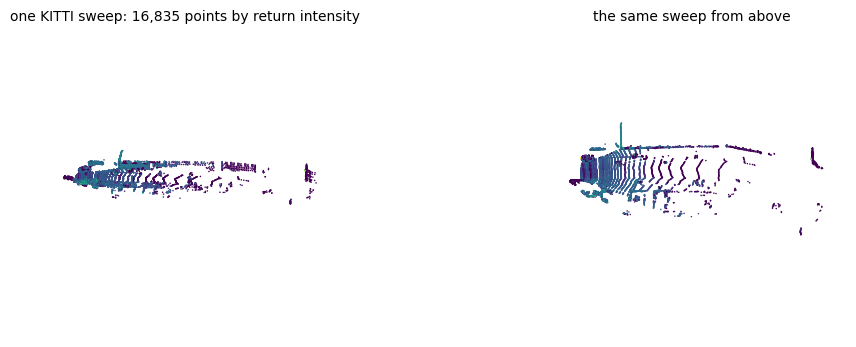

In [7]:
intensity = data["intensity"].squeeze(1)

fig = plt.figure(figsize=(12, 4))
show_cloud(pos, intensity, ax=fig.add_subplot(121, projection="3d"), title=f"one KITTI sweep: {len(pos):,} points by return intensity")
show_cloud(pos, intensity, ax=fig.add_subplot(122, projection="3d"), view=PLAN,  title="the same sweep from above");

![data kitti](../assets/tutorials/driving_sweep.png)

In [8]:
from torch_pointcloud.datasets.kitti import KITTI_CLASSES

for box, label in zip(data["box"], data["label"]):
    distance = float(box[:2].norm())
    print(f"  {KITTI_CLASSES[int(label)]:8s} at {distance:5.1f} m"
          f"  size ({float(box[3]):.2f}, {float(box[4]):.2f}, {float(box[5]):.2f}) m"
          f"  heading {float(box[6]):+.2f} rad"
          f"  bottom z {float(box[2] - box[5] / 2):+.2f} m")

  Car      at   9.6 m  size (3.81, 1.66, 1.62) m  heading -3.12 rad  bottom z -1.79 m
  Cyclist  at  18.0 m  size (2.07, 0.63, 1.85) m  heading -3.15 rad  bottom z -1.64 m
  Cyclist  at  18.4 m  size (1.83, 0.66, 1.76) m  heading -3.09 rad  bottom z -1.63 m
  Car      at  25.1 m  size (4.92, 1.67, 1.46) m  heading -3.14 rad  bottom z -1.60 m
  Cyclist  at  32.3 m  size (1.90, 0.66, 1.78) m  heading -3.15 rad  bottom z -1.51 m
  Car      at  43.7 m  size (4.41, 1.73, 1.42) m  heading -3.23 rad  bottom z -1.48 m
  Car      at  45.3 m  size (4.10, 1.84, 1.51) m  heading -0.07 rad  bottom z -1.38 m
  Car      at   5.4 m  size (3.62, 1.67, 1.61) m  heading -0.00 rad  bottom z -1.67 m


Five cars and three cyclists, from 5.4 m to 45.3 m out. Two things to notice: every box bottom lands within $40$ cm of the $-1.75$ m ground plane, which is the regularity anchor-based detectors exploit. And every heading is within $0.1$ rad of $0$ or $\pi$: this is a straight road and everything on it is aligned with the lane.

## What a pillar encoder needs

PointPillars quantizes the data into a 2D grid of vertical pillars (thus the name!), stacks the points that fall in each one, and runs a 2D CNN over the resulting bird's-eye feature map. The model is parameterized by the following parameters:

| parameter | value | why |
| --- | --- | --- |
| `point_cloud_range` | $(0, -39.68, -3) \to (69.12, 39.68, 1)$ m | forward half only (KITTI annotates the camera view), 4 m of height, sized so the grid divides evenly |
| `voxel_size` | $(0.16, 0.16, 4.0)$ m | 16 cm in the ground plane; the full height in one cell, which is what makes a *pillar* rather than a voxel |
| `max_num_points` | 32 | points per pillar the encoder reads; the stack is padded below it and truncated above |

In [9]:
transform = T.Compose([
    T.Cat(keys=["intensity"], dst_key="x", dim=1),
    T.HardVoxelize(
        pos_key="pos",
        feat_key="x",
        voxel_size=(0.16, 0.16, 4.0),
        point_cloud_range=(0.0, -39.68, -3.0, 69.12, 39.68, 1.0),
        max_num_points=32,
        max_num_voxels=40000,
    ),
])

sample = transform({"pos": pos.clone(), "intensity": data["intensity"].clone()})
print({k: tuple(v.shape) for k, v in sample.items() if torch.is_tensor(v)})

cells = round(69.12 / 0.16) * round(79.36 / 0.16)
counts = sample["voxel_num_points"]
print("occupied pillars:", len(counts), f"of {cells} grid cells ({100 * len(counts) / cells:.2f}%)")
print("points kept:", int(counts.sum()), "of", len(pos))
print("points per pillar: mean", round(float(counts.float().mean()), 1), "| full (32):", int((counts == 32).sum()))

{'pos': (16835, 3), 'intensity': (16835, 1), 'x': (16835, 1), 'voxel': (4055, 32, 4), 'pos_voxel': (4055, 3), 'voxel_num_points': (4055,)}
occupied pillars: 4055 of 214272 grid cells (1.89%)
points kept: 15721 of 16835
points per pillar: mean 3.9 | full (32): 44


`voxel` is $(4055, 32, 4)$ tensor i.e. 4,055 occupied pillars, up to 32 points each and four channels per point $(x, y, z, \text{intensity})$. `pos_voxel` tensor is the integer grid index $(z, y, x)$ of each pillar and `voxel_num_points` says how many of the 32 slots are real.

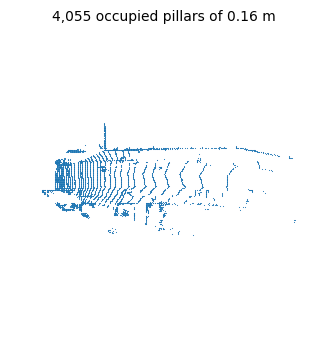

In [10]:
voxel_size = torch.tensor([0.16, 0.16, 4.0])
origin = torch.tensor([0.0, -39.68, -3.0])
centers = sample["pos_voxel"].flip(1).float() * voxel_size + origin + voxel_size / 2

show_cloud(centers, size=0.6, view=PLAN, title=f"{len(centers):,} occupied pillars of 0.16 m");

`pos_voxel` is stored as $(z, y, x)$, so it is flipped before it is scaled back into meters. Every pillar comes out at $z = -1$ m, the middle of the 4 m range, because the grid has exactly one cell in $z$: that is what makes a *pillar* rather than a voxel, and it is why the plot above is a sheet rather than a volume.

Seen from above the 16 cm lattice resolves in the near field: the laser rings of the sweep become rows of cells, and the gaps between rings become empty ones.

## Decoding the head

A detection head emits a dense field of proposals: one per anchor, per grid cell and unfiltered. `model.decode(out)` unpacks that into a flat `Detection3D`. Thresholding and NMS belong to the evaluation protocol, such that you can decide what post-processing to apply and easily swap it out.

`Detection3D` is a plain dictionary of packed tensors containing:

| key | shape | meaning |
| --- | --- | --- |
| `boxes` | $(K, 7)$ | $(c_x, c_y, c_z, d_x, d_y, d_z, \theta)$, full extents |
| `labels` | $(K,)$ | class index per box |
| `scores` | $(K,)$ | confidence per box |
| `batch` | $(K,)$ | which scene of the batch each box belongs to |

`Boxes3D` is the same thing but without `scores`, which is used to represent ground truth.

## Run a pretrained checkpoint

We will use the `create_model` to instantiate the pretrained model `pointpillars.kitti.openpcdet`, a PointPillars trained on the KITTI 3-class split.

In [11]:
model, info = tp.create_model(
    "pointpillars.kitti.openpcdet",
    task="detection",
    pretrained=True,
    return_info=True,
)
model = model.to(device).eval()

print("classes:", info["weights"]["classes"])
print(info["transform"])

classes: ('Car', 'Pedestrian', 'Cyclist')
Compose(
  Cat(keys=('intensity',), allow_missing_keys=False, dst_key='x', dim=1),
  HardVoxelize(keys=('pos',), allow_missing_keys=False, pos_key='pos', voxel_size=(0.16, 0.16, 4.0), point_cloud_range=(0.0, -39.68, -3.0, 69.12, 39.68, 1.0), max_num_points=32, max_num_voxels=40000, feat_key='x', voxel_key='voxel', pos_voxel_key='pos_voxel', num_points_key='voxel_num_points')
)


The `return_info=True` returns the associated information of the model such as the transform used for inference on this specific dataset, and others.

`collate` packs a list of samples into a batch and will create the `batch` tensor index. Pillars are ragged across scenes, so `pos_voxel` is concatenated rather than stacked and the dataloader synthesizes a `batch_pos_voxel` index naming the scene each pillar came from.

In [12]:
from torch_pointcloud.utils.data import collate

batch = collate(
    [info["transform"]({"pos": pos.clone(), "intensity": data["intensity"].clone()})],
    cat_keys=["pos_voxel"],
)

with torch.no_grad():
    out = model(
        batch["voxel"].to(device),
        batch["pos_voxel"].to(device),
        batch["voxel_num_points"].to(device),
        batch["batch_pos_voxel"].to(device),
    )

print("head output:", {k: tuple(v.shape) for k, v in out.items()})
print("anchors:", tuple(model.head.anchors.shape))
# head output: {'cls': (1, 248, 216, 18), 'box': (1, 248, 216, 42), 'dir_cls': (1, 248, 216, 12), 'batch_cls': (1, 321408, 3), 'batch_box': (1, 321408, 7)}
# anchors: (321408, 7)


head output: {'cls': (1, 248, 216, 18), 'box': (1, 248, 216, 42), 'dir_cls': (1, 248, 216, 12), 'batch_cls': (1, 321408, 3), 'batch_box': (1, 321408, 7)}
anchors: (321408, 7)


The head format is specific to the model. Here it contains `cls`, `box` and `dir_cls` which are the three $1 \times 1$ convolutions of the anchor head, still shaped as a $248 \times 216$ bird's-eye feature map. There are 6 anchors per cell (3 classes, each at $0$ and $\pi/2$), so the channel counts are $6 \times 3 = 18$ class logits, $6 \times 7 = 42$ box residuals and $6 \times 2 = 12$ direction-bin logits.

`batch_cls` and `batch_box` are those same predictions flattened and already decoded against the anchors: $248 \times 216 \times 6 = 321\,408$ absolute boxes in meters, and one class logit vector per box.

To actually decode this format into `Detection3D`, we will use `decode` method:

In [13]:
detections = model.decode(out)
print({k: tuple(v.shape) for k, v in detections.items()})
print("score range:", round(float(detections["scores"].min()), 4), "to", round(float(detections["scores"].max()), 4))

above = detections["scores"] > 0.1
boxes, scores = detections["boxes"][above], detections["scores"][above]
labels, index = detections["labels"][above], detections["batch"][above]
print("above score 0.10:", int(above.sum()))

{'boxes': (321408, 7), 'scores': (321408,), 'labels': (321408,), 'batch': (321408,)}
score range: 0.0 to 0.9422
above score 0.10: 218


But this does not apply any filtering. We will manually apply NMS to remove duplicated boxes (or more precisely, boxes that are too close to each other and keep the highest scoring one):

In [14]:
from torch_pointcloud.utils.box3d import nms3d

index = nms3d(boxes, scores, 0.01, batch=index, rotated=True)
boxes, scores, labels = boxes[index].cpu(), scores[index].cpu(), labels[index].cpu()
print("after 3D NMS:", len(boxes))

final = scores > 0.5
print("above score 0.50:", int(final.sum()))

after 3D NMS: 17
above score 0.50: 8


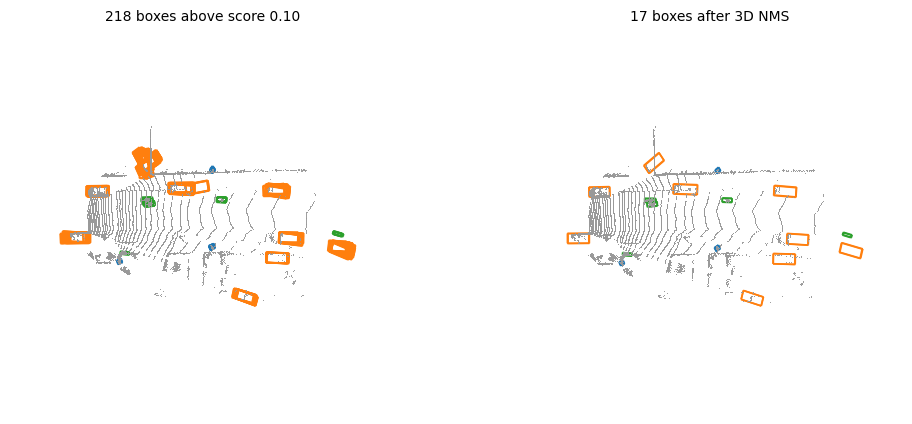

In [15]:
CLASS_COLOR = ["tab:orange", "tab:blue", "tab:green"]  # Car, Pedestrian, Cyclist

classes = info["weights"]["classes"]
near = pos[pos[:, 0] < 50]  # the far quarter of the sweep holds no annotated object
scored = detections["boxes"][above].cpu()
scored_labels = detections["labels"][above].cpu()

stages = [(f"{len(scored)} boxes above score 0.10", scored, scored_labels),
          (f"{len(boxes)} boxes after 3D NMS", boxes, labels)]

fig = plt.figure(figsize=(12, 5))
for index, (title, stage_boxes, stage_labels) in enumerate(stages):
    ax = fig.add_subplot(1, 2, index + 1, projection="3d")
    ax = show_cloud(near, "0.6", ax=ax, title=title, size=0.5, view=PLAN)
    show_boxes(ax, stage_boxes, [CLASS_COLOR[int(label)] for label in stage_labels])

![decoding and filtering](../assets/tutorials/driving_decode.png)

Using the NMS call above filtered 218 boxes to 17 only and removed the low-scoring boxes. Filtering on score confidence above $0.5$ will further reduce the number of boxes down to 8:

In [16]:
for box, score, label in zip(boxes[final], scores[final], labels[final]):
    print(f"  {classes[int(label)]:8s} {float(score):.2f}"
          f"  center ({float(box[0]):5.1f}, {float(box[1]):5.1f}, {float(box[2]):+.2f})"
          f"  size ({float(box[3]):.2f}, {float(box[4]):.2f}, {float(box[5]):.2f})"
          f"  heading {float(box[6]):+.2f}")

  Car      0.94  center (  8.3,   5.0, -0.87)  size (3.80, 1.55, 1.55)  heading +3.16
  Car      0.93  center ( 24.3,   5.4, -0.83)  size (4.45, 1.59, 1.54)  heading +3.11
  Car      0.89  center ( 45.1,  -2.8, -0.62)  size (3.95, 1.67, 1.56)  heading +6.23
  Cyclist  0.84  center ( 32.0,   3.6, -0.62)  size (1.79, 0.63, 1.79)  heading +3.11
  Car      0.80  center ( 42.8,   5.1, -0.73)  size (4.11, 1.59, 1.53)  heading +3.07
  Cyclist  0.77  center ( 18.1,   3.0, -0.74)  size (1.86, 0.69, 1.80)  heading +3.23
  Car      0.76  center (  4.4,  -2.6, -0.94)  size (3.96, 1.61, 1.46)  heading +6.29
  Cyclist  0.74  center ( 17.7,   3.6, -0.81)  size (2.02, 0.60, 1.66)  heading +3.14


Here eight detections are left: five cars and three cyclists, scored 0.74 to 0.94.

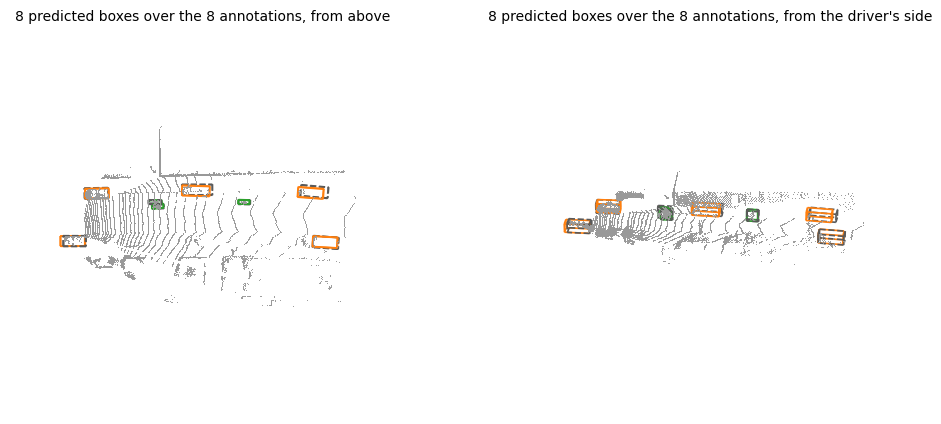

In [17]:
fig = plt.figure(figsize=(12, 5))
shown = f"{int(final.sum())} predicted boxes over the {len(data['box'])} annotations"
for index, (view, angle) in enumerate(((PLAN, "from above"), (SIDE, "from the driver's side"))):
    ax = fig.add_subplot(1, 2, index + 1, projection="3d")
    ax = show_cloud(near, "0.6", ax=ax, size=0.5, view=view, title=f"{shown}, {angle}")
    show_boxes(ax, data["box"], ["0.35"] * len(data["box"]), linestyle="--")
    show_boxes(ax, boxes[final], [CLASS_COLOR[int(label)] for label in labels[final]])


![Eight predicted boxes over the eight annotated boxes on the same sweep, seen from straight above](../assets/tutorials/driving_predictions_bev.png)

![The same eight predicted and annotated boxes seen from the driver's side rather than from above](../assets/tutorials/driving_predictions_perspective.png)

Eight predictions over eight ground truth annotations (!). The predictions are drawn solid and class-colored, the annotations dashed and gray.

In [18]:
from torch_pointcloud.utils.box3d import boxes_iou3d, count_points_in_boxes

overlap = boxes_iou3d(boxes[final], data["box"])
returns = count_points_in_boxes(pos, data["box"])
for row, (score, label) in enumerate(zip(scores[final], labels[final])):
    column = int(overlap[row].argmax())
    print(f"  {classes[int(label)]:8s} {float(score):.2f}"
          f"  ->  {KITTI_CLASSES[int(data['label'][column])]:8s}"
          f"  at {float(data['box'][column, :2].norm()):5.1f} m"
          f"  3D IoU {float(overlap[row, column]):.2f}"
          f"  on {int(returns[column]):4d} points")
print("ground-truth boxes recovered at IoU 0.5:", int((overlap.max(dim=0).values > 0.5).sum()), "of", len(data["box"]))

  Car      0.94  ->  Car       at   9.6 m  3D IoU 0.79  on 1692 points
  Car      0.93  ->  Car       at  25.1 m  3D IoU 0.71  on   92 points
  Car      0.89  ->  Car       at  45.3 m  3D IoU 0.84  on   41 points
  Cyclist  0.84  ->  Cyclist   at  32.3 m  3D IoU 0.84  on   36 points
  Car      0.80  ->  Car       at  43.7 m  3D IoU 0.54  on    8 points
  Cyclist  0.77  ->  Cyclist   at  18.4 m  3D IoU 0.73  on  110 points
  Car      0.76  ->  Car       at   5.4 m  3D IoU 0.75  on  767 points
  Cyclist  0.74  ->  Cyclist   at  18.0 m  3D IoU 0.80  on  110 points
ground-truth boxes recovered at IoU 0.5: 8 of 8


All eight objects are found, with 3D IoU from 0.54 to 0.84.